In [3]:
import numpy as np
import pandas as pd


In [4]:
import os

In [5]:
os.chdir("/")

In [6]:
os.listdir()

['lib64',
 'run',
 'usr',
 'dev',
 'proc',
 'lib32',
 'lib',
 'media',
 'boot',
 'opt',
 'libx32',
 'srv',
 'var',
 'home',
 'bin',
 'sys',
 'sbin',
 'root',
 'etc',
 'tmp',
 'mnt',
 'spam.csv',
 'kaggle',
 '.dockerenv',
 'datalab',
 'tools',
 'content',
 'python-apt',
 'python-apt.tar.xz']

In [7]:
df = pd.read_csv('spam.csv', encoding='latin1')

In [8]:
df.shape

(5572, 5)

In [9]:
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [10]:
df.sample(5)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
5153,ham,Haven't left yet so probably gonna be here til...,NaN,NaN,NaN
248,ham,It didnt work again oh. Ok goodnight then. I.l...,NaN,NaN,NaN
4846,ham,I am in escape theatre now. . Going to watch K...,NaN,NaN,NaN
635,ham,Me n him so funny...,NaN,NaN,NaN
770,ham,Not getting anywhere with this damn job huntin...,NaN,NaN,NaN


# DATA CLEANING

In [11]:
#DROPPING LAST 3 COLS
df.drop(columns=['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], inplace = True)

In [12]:
df.sample(4)

,v1,v2
1943,ham,I got lousy sleep. I kept waking up every 2 ho...
1903,spam,Free entry in 2 a weekly comp for a chance to ...
4406,ham,"Awesome, plan to get here any time after like ..."
798,ham,Ok i msg u b4 i leave my house.


In [13]:
df.rename(columns={'v1':'target', 'v2':'text'}, inplace=True)

In [14]:
df.sample(5)

,target,text
4343,ham,Hi:)did you asked to waheeda fathima about leave?
491,spam,Congrats! 1 year special cinema pass for 2 is ...
4822,ham,:-) :-)
3393,ham,Bull. Your plan was to go floating off to IKEA...
1121,spam,Do you want 750 anytime any network mins 150 t...


In [15]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()

In [16]:
df['target'] = encoder.fit_transform(df['target'])

In [17]:
df.isnull().sum()

,0
target,0
text,0


In [18]:
df.sample(5)

,target,text
5545,0,Hi its in durban are you still on this number
101,0,I'm still looking for a car to buy. And have n...
2846,1,Free-message: Jamster!Get the crazy frog sound...
1983,0,I wnt to buy a BMW car urgently..its vry urgen...
3125,0,U coming 2 pick me?


In [19]:
df.duplicated().sum()

np.int64(403)

In [20]:
df.drop_duplicates(keep='first', inplace=True)

In [21]:
df.shape

(5169, 2)

#EDA

In [22]:
df['target'].value_counts()

,count
target,
0,4516
1,653


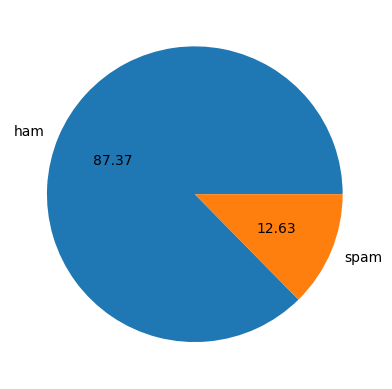

In [23]:
import matplotlib.pyplot as plt
plt.pie(df['target'].value_counts(), labels=['ham', 'spam'], autopct="%0.2f")
plt.show()

In [24]:
import nltk
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [25]:
df['text'].apply(len)

,text
0,111
1,29
2,155
3,49
4,61
...,...
5567,161
5568,37
5569,57
5570,125


In [26]:
df['num_chars'] = df['text'].apply(len)

In [27]:
df.sample(5)

,target,text,num_chars
4711,0,Thats cool princess! I will cover your face in...,64
4154,1,Want a new Video Phone? 750 anytime any networ...,144
3072,0,Somebody should go to andros and steal ice,42
2548,0,Honestly i've just made a lovely cup of tea an...,122
3983,0,"Hey, I missed you tm of last night as my phone...",111


In [28]:
df['num_words'] = df['text'].apply(lambda x : nltk.word_tokenize(x))

In [29]:
df.sample(5)

,target,text,num_chars,num_words
5491,0,U studying in sch or going home? Anyway i'll b...,65,"[U, studying, in, sch, or, going, home, ?, Any..."
4777,0,U R THE MOST BEAUTIFUL GIRL IVE EVER SEEN. U R...,87,"[U, R, THE, MOST, BEAUTIFUL, GIRL, IVE, EVER, ..."
3181,0,"My Parents, My Kidz, My Friends n My Colleague...",130,"[My, Parents, ,, My, Kidz, ,, My, Friends, n, ..."
2764,0,Open rebtel with firefox. When it loads just p...,200,"[Open, rebtel, with, firefox, ., When, it, loa..."
3462,0,i am seeking a lady in the street and a freak ...,73,"[i, am, seeking, a, lady, in, the, street, and..."


In [30]:
df['num_words'] = df['num_words'].apply(len)

In [31]:
df.sample()

,target,text,num_chars,num_words
2662,1,Hello darling how are you today? I would love ...,130,32


In [32]:
df['num_sents'] = df['text'].apply(lambda x : len(nltk.sent_tokenize(x)))

In [33]:
df.sample(5)

,target,text,num_chars,num_words,num_sents
2212,0,This is one of the days you have a billion cla...,58,14,1
3796,0,For The First Time In The History 'Need' 'Comf...,180,59,5
4434,1,Don't b floppy... b snappy & happy! Only gay c...,137,29,3
183,0,"He will, you guys close?",24,7,1
3722,0,We left already we at orchard now.,34,8,1


In [34]:
df.describe()

,target,num_chars,num_words,num_sents
count,5169.000000,5169.000000,5169.000000,5169.000000
mean,0.126330,78.977945,18.455794,1.965564
std,0.332253,58.236293,13.324758,1.448541
min,0.000000,2.000000,1.000000,1.000000
25%,0.000000,36.000000,9.000000,1.000000
50%,0.000000,60.000000,15.000000,1.000000
75%,0.000000,117.000000,26.000000,2.000000
max,1.000000,910.000000,220.000000,38.000000


In [35]:
df[df['target'] == 0].describe()

,target,num_chars,num_words,num_sents
count,4516.0,4516.000000,4516.000000,4516.000000
mean,0.0,70.459256,17.123782,1.820195
std,0.0,56.358207,13.493970,1.383657
min,0.0,2.000000,1.000000,1.000000
25%,0.0,34.000000,8.000000,1.000000
50%,0.0,52.000000,13.000000,1.000000
75%,0.0,90.000000,22.000000,2.000000
max,0.0,910.000000,220.000000,38.000000


In [36]:
df[df['target'] == 1].describe()

,target,num_chars,num_words,num_sents
count,653.0,653.000000,653.000000,653.000000
mean,1.0,137.891271,27.667688,2.970904
std,0.0,30.137753,7.008418,1.488425
min,1.0,13.000000,2.000000,1.000000
25%,1.0,132.000000,25.000000,2.000000
50%,1.0,149.000000,29.000000,3.000000
75%,1.0,157.000000,32.000000,4.000000
max,1.0,224.000000,46.000000,9.000000


#PREPROCESSING

In [37]:
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
import string

In [38]:
def transform_text(text):
  ps = PorterStemmer()
  text = text.lower()

  text = nltk.word_tokenize(text)

  y = []
  for i in text:
    if i.isalnum():
      y.append(i)

  text = y[:];
  y.clear()

  for i in text:
    if i not in stopwords.words("english") and i not in string.punctuation:
      y.append(i)

  text = y[:]
  y.clear()

  for i in text:
    y.append(ps.stem(i))

  return y

In [39]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [40]:
transform_text("hi this is UDIT Garg. i am 18$ Yrs old")

['hi', 'udit', 'garg', '18', 'yr', 'old']

In [41]:
df['text'].apply(transform_text)

,text
0,"[go, jurong, point, crazi, avail, bugi, n, gre..."
1,"[ok, lar, joke, wif, u, oni]"
2,"[free, entri, 2, wkli, comp, win, fa, cup, fin..."
3,"[u, dun, say, earli, hor, u, c, alreadi, say]"
4,"[nah, think, goe, usf, live, around, though]"
...,...
5567,"[2nd, time, tri, 2, contact, u, pound, prize, ..."
5568,"[b, go, esplanad, fr, home]"
5569,"[piti, mood, suggest]"
5570,"[guy, bitch, act, like, interest, buy, someth,..."


In [42]:
df['transformed_text'] =  df['text'].apply(transform_text)

In [43]:
from wordcloud import WordCloud
wc = WordCloud(width = 500, height = 500, min_font_size = 10, background_color = 'white')

In [44]:
ham_wc = wc.generate(df[df['target'] == 0]['transformed_text'].apply(lambda x: ' '.join(x)).str.cat(sep = ' '))

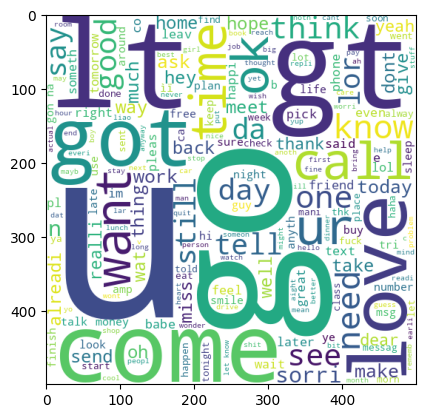

In [45]:
plt.imshow(ham_wc)

In [46]:
spam_corpus = []

for msg in df[df['target'] == 1]['transformed_text'].tolist():
  for word in msg:
    spam_corpus.append(word)


In [47]:
len(spam_corpus)

9939

In [48]:
from collections import Counter
pd.DataFrame(Counter(spam_corpus).most_common(30))

,0,1
0,call,320
1,free,191
2,2,155
3,txt,141
4,text,122
5,u,119
6,ur,119
7,mobil,114
8,stop,104
9,repli,103


In [49]:
ham_corpus = []

for msg in df[df['target'] == 0]['transformed_text'].tolist():
  for word in msg:

    ham_corpus.append(word)


In [50]:
len(ham_corpus)

35404

In [51]:
pd.DataFrame(Counter(ham_corpus).most_common(30))

,0,1
0,u,883
1,go,404
2,get,349
3,gt,288
4,lt,287
5,2,284
6,come,275
7,got,236
8,know,236
9,like,234


#TRAINING

In [52]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
cv = CountVectorizer()
Tfidf = TfidfVectorizer(max_features = 3000)

In [53]:
X = Tfidf.fit_transform(df['transformed_text'].apply(lambda x: ' '.join(x))).toarray()

In [54]:
X.shape

(5169, 3000)

In [55]:
y = df['target'].values

In [56]:
y

array([0, 0, 1, ..., 0, 0, 0])

In [57]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score

In [58]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size = 0.2, random_state = 7)

In [59]:
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB

In [60]:
gnb = GaussianNB()
mnb = MultinomialNB()
bnb = BernoulliNB()

In [61]:
gnb.fit(X_train, y_train)
y_pred1 = gnb.predict(X_test)
print(accuracy_score(y_test, y_pred1))
print(confusion_matrix(y_test, y_pred1))
print(precision_score(y_test, y_pred1))

0.8588007736943907
[[766 120]
 [ 26 122]]
0.5041322314049587


In [62]:
mnb.fit(X_train, y_train)
y_pred2 = mnb.predict(X_test)
print(accuracy_score(y_test, y_pred2))
print(confusion_matrix(y_test, y_pred2))
print(precision_score(y_test, y_pred2))

0.9690522243713733
[[885   1]
 [ 31 117]]
0.9915254237288136


In [63]:
bnb.fit(X_train, y_train)
y_pred3 = bnb.predict(X_test)
print(accuracy_score(y_test, y_pred3))
print(confusion_matrix(y_test, y_pred3))
print(precision_score(y_test, y_pred3))

0.9748549323017408
[[883   3]
 [ 23 125]]
0.9765625


In [64]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

In [65]:
svc = SVC(kernel='sigmoid', gamma=1.0)
knc = KNeighborsClassifier()
mnb = MultinomialNB()
dtc = DecisionTreeClassifier(max_depth=5)
lrc = LogisticRegression(solver='liblinear', penalty='l1')
rfc = RandomForestClassifier(n_estimators=50, random_state=2)
abc = AdaBoostClassifier(n_estimators=50, random_state=2)
bc = BaggingClassifier(n_estimators=50, random_state=2)
etc = ExtraTreesClassifier(n_estimators=50, random_state=2)
gbdt = GradientBoostingClassifier(n_estimators=50,random_state=2)
xgb = XGBClassifier(n_estimators=50,random_state=2)

In [66]:
clfs = {
    'SVC' : svc,
    'KN' : knc,
    'NB': mnb,
    'DT': dtc,
    'LR': lrc,
    'RF': rfc,
    'AdaBoost': abc,
    'BgC': bc,
    'ETC': etc,
    'GBDT':gbdt,
    'xgb':xgb
}

In [67]:

def train_classifier(clf,X_train,y_train,X_test,y_test):
    clf.fit(X_train,y_train)
    y_pred = clf.predict(X_test)
    accuracy = accuracy_score(y_test,y_pred)
    precision = precision_score(y_test,y_pred)

    return accuracy,precision

In [68]:
train_classifier(svc,X_train,y_train,X_test,y_test)

(0.9709864603481625, 0.9758064516129032)

In [69]:

accuracy_scores = []
precision_scores = []

for name,clf in clfs.items():

    current_accuracy,current_precision = train_classifier(clf, X_train,y_train,X_test,y_test)

    print("For ",name)
    print("Accuracy - ",current_accuracy)
    print("Precision - ",current_precision)

    accuracy_scores.append(current_accuracy)
    precision_scores.append(current_precision)

For  SVC
Accuracy -  0.9709864603481625
Precision -  0.9758064516129032
For  KN
Accuracy -  0.9032882011605415
Precision -  1.0
For  NB
Accuracy -  0.9690522243713733
Precision -  0.9915254237288136
For  DT
Accuracy -  0.9352030947775629
Precision -  0.8857142857142857
For  LR
Accuracy -  0.9477756286266924
Precision -  0.9272727272727272
For  RF
Accuracy -  0.9729206963249516
Precision -  1.0
For  AdaBoost
Accuracy -  0.9100580270793037
Precision -  0.8021978021978022
For  BgC
Accuracy -  0.9622823984526112
Precision -  0.8865248226950354
For  ETC
Accuracy -  0.9729206963249516
Precision -  0.9545454545454546
For  GBDT
Accuracy -  0.9468085106382979
Precision -  0.9603960396039604
For  xgb
Accuracy -  0.965183752417795
Precision -  0.9375


In [81]:
performance_df = pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy':accuracy_scores,'Precision':precision_scores}).sort_values('Precision',ascending=False)


In [71]:
performance_df1 = pd.melt(performance_df, id_vars = "Algorithm")


In [72]:
performance_df1

,Algorithm,variable,value
0,KN,Accuracy,0.903288
1,RF,Accuracy,0.972921
2,NB,Accuracy,0.969052
3,SVC,Accuracy,0.970986
4,GBDT,Accuracy,0.946809
5,ETC,Accuracy,0.972921
6,xgb,Accuracy,0.965184
7,LR,Accuracy,0.947776
8,BgC,Accuracy,0.962282
9,DT,Accuracy,0.935203


In [73]:
temp_df = pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy_max_ft_3000':accuracy_scores,'Precision_max_ft_3000':precision_scores}).sort_values('Precision_max_ft_3000',ascending=False)


In [74]:
temp_df = pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy_scaling':accuracy_scores,'Precision_scaling':precision_scores}).sort_values('Precision_scaling',ascending=False)


In [75]:
new_df = performance_df.merge(temp_df,on='Algorithm')


In [76]:
new_df_scaled = new_df.merge(temp_df,on='Algorithm')


In [77]:
temp_df = pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy_num_chars':accuracy_scores,'Precision_num_chars':precision_scores}).sort_values('Precision_num_chars',ascending=False)


In [78]:
new_df_scaled.merge(temp_df,on='Algorithm')


,Algorithm,Accuracy,Precision,Accuracy_scaling_x,Precision_scaling_x,Accuracy_scaling_y,Precision_scaling_y,Accuracy_num_chars,Precision_num_chars
0,KN,0.903288,1.000000,0.903288,1.000000,0.903288,1.000000,0.903288,1.000000
1,RF,0.972921,1.000000,0.972921,1.000000,0.972921,1.000000,0.972921,1.000000
2,NB,0.969052,0.991525,0.969052,0.991525,0.969052,0.991525,0.969052,0.991525
3,SVC,0.970986,0.975806,0.970986,0.975806,0.970986,0.975806,0.970986,0.975806
4,GBDT,0.946809,0.960396,0.946809,0.960396,0.946809,0.960396,0.946809,0.960396
5,ETC,0.972921,0.954545,0.972921,0.954545,0.972921,0.954545,0.972921,0.954545
6,xgb,0.965184,0.937500,0.965184,0.937500,0.965184,0.937500,0.965184,0.937500
7,LR,0.947776,0.927273,0.947776,0.927273,0.947776,0.927273,0.947776,0.927273
8,BgC,0.962282,0.886525,0.962282,0.886525,0.962282,0.886525,0.962282,0.886525
9,DT,0.935203,0.885714,0.935203,0.885714,0.935203,0.885714,0.935203,0.885714


In [87]:
svc = SVC(kernel='sigmoid', gamma=1.0,probability=True)
mnb = MultinomialNB()
etc = ExtraTreesClassifier(n_estimators=50, random_state=2)

from sklearn.ensemble import VotingClassifier
voting = VotingClassifier(estimators=[('nb', mnb), ('kn', knc), ('rf', rfc)],voting='soft')

In [88]:
voting.fit(X_train,y_train)


VotingClassifier(estimators=[('nb', MultinomialNB()),
                             ('kn', KNeighborsClassifier()),
                             ('rf',
                              RandomForestClassifier(n_estimators=50,
                                                     random_state=2))],
                 voting='soft')

In [89]:
y_pred = voting.predict(X_test)
print("Accuracy",accuracy_score(y_test,y_pred))
print("Precision",precision_score(y_test,y_pred))

Accuracy 0.9632495164410058
Precision 1.0


In [90]:
estimators=[('nb', mnb), ('kn', knc), ('rf', rfc)]
final_estimator=RandomForestClassifier()

In [91]:
from sklearn.ensemble import StackingClassifier

In [92]:
clf = StackingClassifier(estimators=estimators, final_estimator=final_estimator)


In [93]:
clf.fit(X_train,y_train)
y_pred = clf.predict(X_test)
print("Accuracy",accuracy_score(y_test,y_pred))
print("Precision",precision_score(y_test,y_pred))

Accuracy 0.9796905222437138
Precision 0.950354609929078


In [94]:
import pickle
pickle.dump(Tfidf,open('vectorizer.pkl','wb'))
pickle.dump(rfc,open('model.pkl','wb'))


In [95]:
rfc.fit(X_train, y_train)
pickle.dump(rfc, open('model.pkl', 'wb'))